<a href="https://colab.research.google.com/github/greeshmapj/AI-ML-nov2025-assignments/blob/main/Greeshma_Assignment7_NLP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**1. Load Datset**

In [810]:
import pandas as pd

df = pd.read_csv('/content/judge-1377884607_tweet_product_company.csv', encoding='latin1')
df.head()

,tweet_text,emotion_in_tweet_is_directed_at,is_there_an_emotion_directed_at_a_brand_or_product
0,.@wesley83 I have a 3G iPhone. After 3 hrs twe...,iPhone,Negative emotion
1,@jessedee Know about @fludapp ? Awesome iPad/i...,iPad or iPhone App,Positive emotion
2,@swonderlin Can not wait for #iPad 2 also. The...,iPad,Positive emotion
3,@sxsw I hope this year's festival isn't as cra...,iPad or iPhone App,Negative emotion
4,@sxtxstate great stuff on Fri #SXSW: Marissa M...,Google,Positive emotion


In [811]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9093 entries, 0 to 9092
Data columns (total 3 columns):
 #   Column                                              Non-Null Count  Dtype 
---  ------                                              --------------  ----- 
 0   tweet_text                                          9092 non-null   object
 1   emotion_in_tweet_is_directed_at                     3291 non-null   object
 2   is_there_an_emotion_directed_at_a_brand_or_product  9093 non-null   object
dtypes: object(3)
memory usage: 213.2+ KB


**INSIGHT**
* tweet_text → Main input (text data)
* emotion_in_tweet_is_directed_at → Drop (unnecessary)
* is_there_an_emotion_directed_at_a_brand_or_product → Target column
* Missinng values present

#**2. Drop Unnecessary Column**

In [812]:
df = df.drop(columns=['emotion_in_tweet_is_directed_at'])

In [813]:
df.head(3)

,tweet_text,is_there_an_emotion_directed_at_a_brand_or_product
0,.@wesley83 I have a 3G iPhone. After 3 hrs twe...,Negative emotion
1,@jessedee Know about @fludapp ? Awesome iPad/i...,Positive emotion
2,@swonderlin Can not wait for #iPad 2 also. The...,Positive emotion


#**3. Remove Duplicates**

In [814]:
df.duplicated(subset=['tweet_text']).sum()

np.int64(27)

In [815]:
df = df.drop_duplicates(subset=['tweet_text'])
df.duplicated(subset=['tweet_text']).sum()

np.int64(0)




#**4. Handling Missing Values**

In [816]:
round(df.isnull().mean()*100,2)

,0
tweet_text,0.01
is_there_an_emotion_directed_at_a_brand_or_product,0.00


In [817]:
df = df.dropna(subset=['tweet_text'])

In [818]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9065 entries, 0 to 9092
Data columns (total 2 columns):
 #   Column                                              Non-Null Count  Dtype 
---  ------                                              --------------  ----- 
 0   tweet_text                                          9065 non-null   object
 1   is_there_an_emotion_directed_at_a_brand_or_product  9065 non-null   object
dtypes: object(2)
memory usage: 212.5+ KB


#**5. Renaming Columns**

In [819]:
df.rename(columns={
    'tweet_text': 'text',
    'is_there_an_emotion_directed_at_a_brand_or_product': 'sentiment'
}, inplace=True)

In [820]:
df.head()

,text,sentiment
0,.@wesley83 I have a 3G iPhone. After 3 hrs twe...,Negative emotion
1,@jessedee Know about @fludapp ? Awesome iPad/i...,Positive emotion
2,@swonderlin Can not wait for #iPad 2 also. The...,Positive emotion
3,@sxsw I hope this year's festival isn't as cra...,Negative emotion
4,@sxtxstate great stuff on Fri #SXSW: Marissa M...,Positive emotion


#**6. Explore Target Variable**

In [821]:
df['sentiment'].value_counts()

,count
sentiment,
No emotion toward brand or product,5372
Positive emotion,2968
Negative emotion,569
I can't tell,156


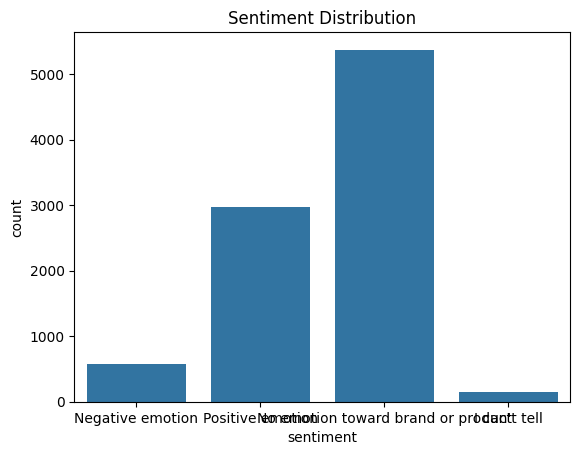

In [822]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='sentiment', data=df)
plt.title("Sentiment Distribution")
plt.show()

**INSIGHT**
* Dataset contains 4 classes:
  1. Positive
  2. Negative
  3. Neutral
  4. No Idea
* Class Imbalance exists.

#**7. Text Preprocessing**

In [823]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords')
nltk.download('wordnet')
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

#text cleaning
def clean_text(text):
  text = text.lower()
  text = re.sub(r'http\S+', '', text)   # remove URLs
  text = re.sub(r'@\w+', '', text)      # remove mentions
  text = re.sub(r'#', '', text)
  text = re.sub(r'[^a-zA-Z]', ' ', text) # remove special chars
  words = text.split()
  words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]
  return ' '.join(words)


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [824]:
#Apply fn
df['clean_text'] = df['text'].apply(clean_text)

#**8. Encode Target Variable**

In [825]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['label'] = le.fit_transform(df['sentiment'])

#**9. Train-Test Split**

In [826]:
from sklearn.model_selection import train_test_split

X = df['clean_text']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify = y
)

#**10. Tokenization**

In [827]:
from tensorflow.keras.preprocessing.text import Tokenizer

tokenizer = Tokenizer(num_words=12000)
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

#**11. Padding**


In [828]:
#Calculate tweet lengths
df['text_length'] = df['clean_text'].apply(lambda x: len(x.split()))

#Check Distribution
df['text_length'].describe()

,text_length
count,9065.000000
mean,11.403971
std,3.182217
min,1.000000
25%,9.000000
50%,12.000000
75%,14.000000
max,27.000000


**INSIGHT**
* Maximum length is 24 words
* 75% of tweets have ≤ 12 words
* max_len = 25(To ensure that slightly longer tweets are also captured without excessive padding.)


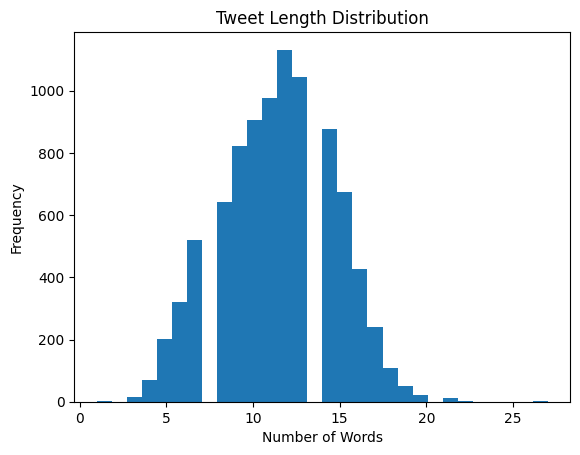

In [829]:
plt.hist(df['text_length'], bins=30)
plt.title("Tweet Length Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.show()

In [830]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

max_len = 25

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len, padding='post')


#**12. Build Model(SimpleRNN)**

In [831]:
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, Dense, Dropout
from tensorflow.keras.models import Sequential

model_rnn = Sequential([
    Embedding(input_dim=12000, output_dim=64),
    SimpleRNN(128),
    Dense(32, activation='relu'),
    Dropout(0.5),
    Dense(4, activation='softmax')
])

#**13. Compile Model**

In [832]:
model_rnn.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

#**14. Train Model**

In [833]:
history = model_rnn.fit(
    X_train_pad, y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_test_pad, y_test)
)

Epoch 1/10
227/227 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.5636 - loss: 0.9853 - val_accuracy: 0.5924 - val_loss: 0.9340
Epoch 2/10
227/227 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.5927 - loss: 0.9578 - val_accuracy: 0.5924 - val_loss: 0.9230
Epoch 3/10
227/227 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.5913 - loss: 0.9487 - val_accuracy: 0.5924 - val_loss: 0.9257
Epoch 4/10
227/227 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.5927 - loss: 0.9485 - val_accuracy: 0.5924 - val_loss: 0.9226
Epoch 5/10
227/227 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.5927 - loss: 0.9486 - val_accuracy: 0.5924 - val_loss: 0.9200
Epoch 6/10
227/227 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.5927 - loss: 0.9434 - val_accuracy: 0.5924 - val_loss: 0.9246
Epoch 7/10
227/227 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.5910 - loss: 0.9408 - val_accuracy: 0.5924 - val_loss: 0.9204
Epoch 8/10
227/227 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.5927 - loss: 0.9398 - val_accu

#**15. Evaluate Model**

In [834]:
loss, accuracy = model_rnn.evaluate(X_test_pad, y_test)
print("Accuracy:", accuracy)

57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5924 - loss: 0.9234
Accuracy: 0.5923883318901062


**INSIGHT**
* Model Accuracy = 59.24%
* Decent for SimpleRNN, but not great

#**16. Predictions**

In [835]:
import numpy as np

y_pred = model_rnn.predict(X_test_pad)
y_pred_classes = np.argmax(y_pred, axis=1)


57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


#**17. Classification Report**

In [836]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, y_pred_classes))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        31
           1       0.00      0.00      0.00       114
           2       0.59      1.00      0.74      1074
           3       0.00      0.00      0.00       594

    accuracy                           0.59      1813
   macro avg       0.15      0.25      0.19      1813
weighted avg       0.35      0.59      0.44      1813



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


**INSIGHT**
* Class 2 dominates heavily
* Class 0 has very few samples
* Model is biased towards class 2

#**18. Confusion Matrix**

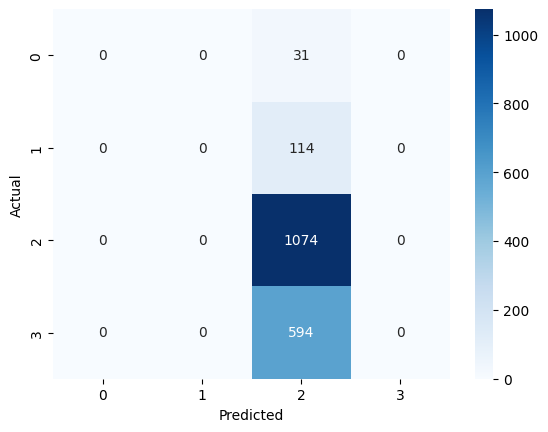

In [837]:
cm = confusion_matrix(y_test, y_pred_classes)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

**INSIGHT**
* Many samples predicted as class 2
* Class 0 almost ignored
* Class 3 often confused with class 2

The confusion matrix shows that the model performs well for the majority class (class 2), but fails to correctly classify minority classes such as class 0. There is also noticeable confusion between class 2 and class 3, indicating overlapping features between these sentiments.

#**19. LSTM Model**

##**Create Validation Set**



In [838]:
X_train_pad, X_val_pad, y_train, y_val = train_test_split(
    X_train_pad, y_train, test_size=0.1, random_state=42
)

In [839]:
from tensorflow.keras.layers import Bidirectional

model = Sequential([
    Embedding(input_dim=15000, output_dim=128, input_length=max_len),
    Bidirectional(LSTM(64, return_sequences=True)),
    Dropout(0.3),
    Bidirectional(LSTM(32)),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(4, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [841]:
from tensorflow.keras.optimizers import Adam

model_lstm.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=Adam(learning_rate=0.007),
    metrics=['accuracy']
)

##**Early Stopping**

In [842]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [851]:
#Train Model
history_lstm = model_lstm.fit(
    X_train_pad, y_train,
    epochs=15,
    batch_size=32,
    validation_data=(X_val_pad, y_val),
    callbacks=[early_stop]
)

Epoch 1/15
204/204 ━━━━━━━━━━━━━━━━━━━━ 8s 40ms/step - accuracy: 0.8083 - loss: 0.5369 - val_accuracy: 0.6267 - val_loss: 1.0976
Epoch 2/15
204/204 ━━━━━━━━━━━━━━━━━━━━ 13s 53ms/step - accuracy: 0.8242 - loss: 0.4697 - val_accuracy: 0.6336 - val_loss: 1.1212
Epoch 3/15
204/204 ━━━━━━━━━━━━━━━━━━━━ 16s 30ms/step - accuracy: 0.8239 - loss: 0.4400 - val_accuracy: 0.6143 - val_loss: 1.2237


In [844]:
#Evaluate
loss, accuracy = model_lstm.evaluate(X_test_pad, y_test)
print("Accuracy:", accuracy)

57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6602 - loss: 0.8984
Accuracy: 0.6602316498756409


**INSIGHT**
* The LSTM model achieved an accuracy of approximately 67%, outperforming the SimpleRNN model.
* This improvement is due to the LSTM’s ability to capture long-term dependencies in sequential text data using its memory cell structure

In [845]:
#predictions
y_pred_lstm = model_lstm.predict(X_test_pad)
y_pred_classes_lstm = np.argmax(y_pred_lstm, axis=1)

57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step


In [846]:
#Classification Report
print(classification_report(y_test, y_pred_classes_lstm))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        31
           1       0.00      0.00      0.00       114
           2       0.70      0.84      0.76      1074
           3       0.57      0.49      0.52       594

    accuracy                           0.66      1813
   macro avg       0.32      0.33      0.32      1813
weighted avg       0.60      0.66      0.62      1813



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


**INSIGHT**

* The model is biased towards the majority class (class 2), as evidenced by its high recall for that class and poor performance on minority classes.
* This indicates that the model has learned dominant patterns but struggles to generalize across all sentiment categories.

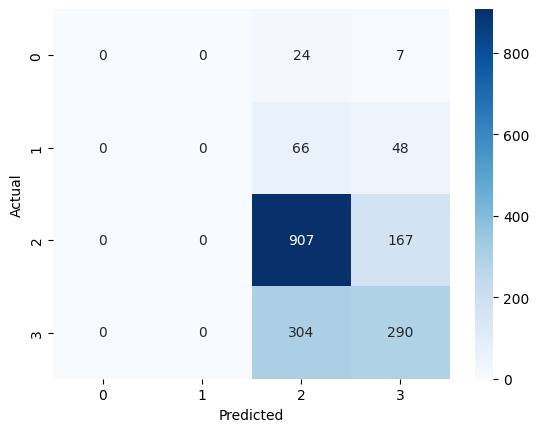

In [849]:
#Confusion Matrix
cm = confusion_matrix(y_test, y_pred_classes_lstm)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

**CONCLUSION**
* LSTM outperformed SimpleRNN due to better contextual understanding, but both models were affected by class imbalance and noisy data, limiting their overall performance.
* However, both models exhibited a strong bias towards the majority class, resulting in high performance for dominant classes and poor performance for minority classes.